# 2-Sample t-Test: Solar vs. Wind Power Generation
**Dataset:** Hourly Electricity Consumption and Production (Kaggle)

<b>Desiree Valois</b>
<br>Computer Engineer

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower


In [2]:
# load CLT dataset (output from central-limit-theorem-solar-wind.ipynb)
df = pd.read_csv(r"dataset/electricity-clt-dataset.csv")
df

,Solar,Wind
0,145.133333,705.033333
1,251.333333,694.466667
2,151.533333,976.033333
3,236.166667,801.300000
4,161.466667,874.933333
5,130.966667,620.266667
6,213.933333,967.900000
7,152.866667,746.500000
8,151.000000,860.766667
9,203.600000,1011.000000


In [3]:
# summary of statistics
df.describe()

,Solar,Wind
count,50.000000,50.000000
mean,172.486667,762.614000
std,44.133999,121.216637
min,97.200000,491.900000
25%,139.625000,686.366667
50%,163.183333,754.400000
75%,208.350000,834.516667
max,295.666667,1011.000000


## Data Cleaning - Remove 3-sigma outliers

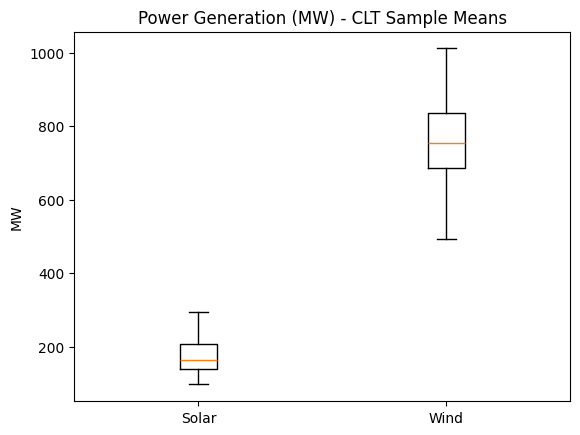

Cleaned dataset: 50 rows


In [4]:
# removing 3-sigma outliers from both columns
for col in ["Solar", "Wind"]:
    z = stats.zscore(df[col])
    df = df[(z > -3) & (z < 3)]

# boxplot after cleaning
plt.boxplot([df["Solar"], df["Wind"]], tick_labels=["Solar", "Wind"])
plt.title("Power Generation (MW) - CLT Sample Means")
plt.ylabel("MW")
plt.show()

print(f"Cleaned dataset: {len(df)} rows")

## Statistical Question
Is the mean power generation of **Wind** significantly higher than **Solar**?

## Hypotheses
**H₀:** μ_Wind ≤ μ_Solar

**Hₐ:** μ_Wind > μ_Solar  (right-tailed test)

## Normality Test

In [5]:
alpha = 0.05

for col in ["Solar", "Wind"]:
    w_stat, p_value = stats.shapiro(df[col])
    print(f"{col}:")
    print(f"  W-statistic: {w_stat:.4f}")
    print(f"  P-value:     {p_value:.4f}")
    if p_value < alpha:
        print("  Result: Non-normal data")
    else:
        print("  Result: Normal data (CLT satisfied)")
    print()

Solar:
  W-statistic: 0.9614
  P-value:     0.1022
  Result: Normal data (CLT satisfied)

Wind:
  W-statistic: 0.9807
  P-value:     0.5800
  Result: Normal data (CLT satisfied)



## F-Test for Equality of Variances
**H₀:** σ²_Wind = σ²_Solar

**Hₐ:** σ²_Wind ≠ σ²_Solar

In [6]:
var_solar = df["Solar"].var(ddof=1)
var_wind = df["Wind"].var(ddof=1)

# F-statistic (larger variance in numerator)
if var_wind > var_solar:
    f_stat = var_wind / var_solar
    dof1 = df["Wind"].count() - 1
    dof2 = df["Solar"].count() - 1
else:
    f_stat = var_solar / var_wind
    dof1 = df["Solar"].count() - 1
    dof2 = df["Wind"].count() - 1

p_value = 1 - stats.f.cdf(f_stat, dof1, dof2)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < alpha:
    print("Unequal variances --> Use Welch's t-test (equal_var=False)")
    equal_var = False
else:
    print("Equal variances --> Use Student's t-test (equal_var=True)")
    equal_var = True

F-statistic: 7.5436
P-value:     0.0000
Unequal variances --> Use Welch's t-test (equal_var=False)


## 2-Sample t-Test (Welch's, Right-Tailed)
**H₀:** μ_Wind ≤ μ_Solar

**Hₐ:** μ_Wind > μ_Solar

In [7]:
t_stat, p_value = stats.ttest_ind(
    df["Wind"], df["Solar"],
    alternative="greater",
    equal_var=equal_var
)

print(f"t-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < alpha:
    print("Decision: REJECT H₀")
    print("Wind power generation is significantly higher than Solar.")
else:
    print("Decision: FAIL TO REJECT H₀")
    print("No significant difference found.")

t-statistic: 32.3472
P-value:     0.0000
Decision: REJECT H₀
Wind power generation is significantly higher than Solar.


## Power of the Test

In [8]:
# Cohen's d (effect size)
wind_mean = df["Wind"].mean()
solar_mean = df["Solar"].mean()
wind_std = df["Wind"].std(ddof=1)

cohens_d = abs((wind_mean - solar_mean) / wind_std)
print(f"Cohen's d: {cohens_d:.4f}")

# Power of the test
power = TTestIndPower().power(
    effect_size=cohens_d,
    nobs1=df["Wind"].count(),
    alpha=0.05,
    alternative="larger"
)
print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 4.8684
Power of the test: 100.00%
